# Constant Q Transfrom

This notebook explores the constant Q transform to extract pitch energies over the whole [scientific pitch](https://en.wikipedia.org/wiki/Scientific_pitch_notation) spectrum aka the octaves of western note notation.

**Conclusions:**
- pad each chunk by 1 (times 1024) before CQT for smoother chunked CQT
- n_new=1, n_carryover=8, n_pad=1 good settings
- factor=1.5|2.0 gives sharper results without that much spill-over in adjanced bins
  - for some visualizations, factor of < 1 might also be good; a powerful parameters
- chunk_size_samples=1024
- all remaining CQT paramters left on default
- normalize CQT spectrum energy with a running minimal max_norm value `cqt / max(min_max_norm, cqt.max()`
    - threshold (afterwards) if required with thresholds in the range 0.6-0.8
- audioflux vs. librosa
  - both implementations lead to the same results
  - audioflux's CQT beats librosa on small audio chunks, but is slower on larger ones (e.g. 5s+)

In [1]:
import numpy as np
import librosa
import audioflux as af
import matplotlib.pyplot as plt
from audioflux.display import fill_spec
from audioflux.type import (SpectralFilterBankScaleType, SpectralFilterBankStyleType, SpectralFilterBankNormalType, ChromaDataNormalType, SpectralDataType)
from audioflux.utils import note_to_hz
import IPython.display as ipd
import plotly.express as px
import pandas as pd

### Functions

In [2]:
def _add_sepc(ax, y, y_cqt):
    img = fill_spec(
        np.abs(y_cqt),
        axes=ax,
        x_coords=cqt_obj.x_coords(y.shape[-1]),
        x_axis='time',
        title='Constant-Q power spectrum'
    )
    ax.set_ylabel('Notes')
    ax.set_yticks(range(y_cqt.shape[0]))
    ax.set_yticklabels(sum(note_range, []))
    ax.tick_params(axis="y", labelsize=6)
    
    return img

In [3]:
def plot_cqt(y, y_cqt):
    fig, ax = plt.subplots(figsize=(10, 10))
    img = _add_sepc(ax, y, y_cqt)
    fig.colorbar(img, ax=ax)

In [4]:
def plot_cqts(y, y_cqt_1, y_cqt_2):
    fig, ax = plt.subplots(ncols=2, figsize=(14, 10), sharey=True)
    
    img = _add_sepc(ax[0], y, y_cqt_1)
    fig.colorbar(img, ax=ax[0])
    img = _add_sepc(ax[1], y, y_cqt_2)
    fig.colorbar(img, ax=ax[1])
    
    #fig.colorbar(img, ax=ax[0])

### Load audio

In [96]:
# 880Hz tone
#sample_path = af.utils.sample_path('880')
#y, sr = af.read(sample_path)

In [98]:
# midi file (increasing notes over one octave)
#y, sr = af.read("audio/midi_chunk/midi_chunk_oneoctave_c2plus.mp3")
y, sr = af.read("audio/midi_chunk/midi_chunk_twooctaves_c2plus.mp3")

In [84]:
# song file (increasing notes over one octave)
#y, sr = af.read("audio/songs/tell-me-the-truth-260010.mp3")
#y = y[5*sr:10*sr]
#y = y[20*sr:25*sr]
#y = y[60*sr:65*sr]

### Audio details

In [8]:
print(
    f"{y.shape} samples\n",
    f"{sr} sample rate\n",
    f"{y.shape[0] / sr} seconds\n",
    f"{y.max()} / {y.min()} min/max"
)

(220500,) samples
 44100 sample rate
 5.0 seconds
 1.025587797164917 / -1.0280141830444336 min/max


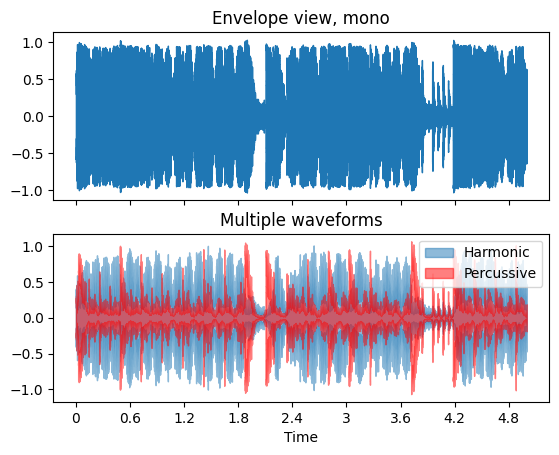

In [9]:
y_harm, y_perc = librosa.effects.hpss(y)

fig, ax = plt.subplots(nrows=2, sharex=True)
librosa.display.waveshow(y, sr=sr, axis="m", ax=ax[0])
ax[0].set(title='Envelope view, mono')
ax[0].label_outer()
librosa.display.waveshow(y_harm, sr=sr, alpha=0.5, ax=ax[1], label='Harmonic')
librosa.display.waveshow(y_perc, sr=sr, color='r', alpha=0.5, ax=ax[1], label='Percussive')
ax[1].set(title='Multiple waveforms')
ax[1].legend()

In [10]:
ipd.Audio(y, rate=sr)

## Constants

In [11]:
NOTE_NAMES = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']

## Settings

In [12]:
low_octave = 1
high_octave = 7

n_octaves = high_octave - low_octave + 1
n_notes_per_octave = 12

note_range = [[f"{nn}{on}" for nn in NOTE_NAMES] for on in range(low_octave, high_octave + 1)]

low_freq = note_to_hz(f"C{low_octave}")
high_freq = note_to_hz(f"A{low_octave + n_octaves - 1}")
high_freq_limit = sr/2  # Nyquist frequency, aka what the sample can support
assert high_freq <= high_freq_limit

slide_length = hop_length = 1024

In [13]:
print(f"Extracting {n_octaves} octaves ranging from octave {low_octave} to octave {high_octave}")
print(f"Extracting notes from C{low_octave} to A{high_octave}")
print(f"Extracting log-scale frequencies from {low_freq} Hz to {high_freq} Hz")

Extracting 7 octaves ranging from octave 1 to octave 7
Extracting notes from C1 to A7
Extracting log-scale frequencies from 32.70319566257483 Hz to 3520.0 Hz


In [14]:
cqt_obj = af.CQT(
    num=n_octaves*n_notes_per_octave,
    samplate=sr,
    low_fre=low_freq,
    bin_per_octave=n_notes_per_octave,
    slide_length=slide_length,
    normal_type=SpectralFilterBankNormalType.AREA  # SpectralFilterBankNormalType.NONE | AREA | BAND_WIDTH
)

## CQT exploration using whole audio

In [15]:
y_cqt = cqt_obj.cqt(y)
print(y_cqt.shape, y_cqt.min(), y_cqt.max())

(84, 216) (-24.212845-3.1716027j) (21.964096-1.3491489j)


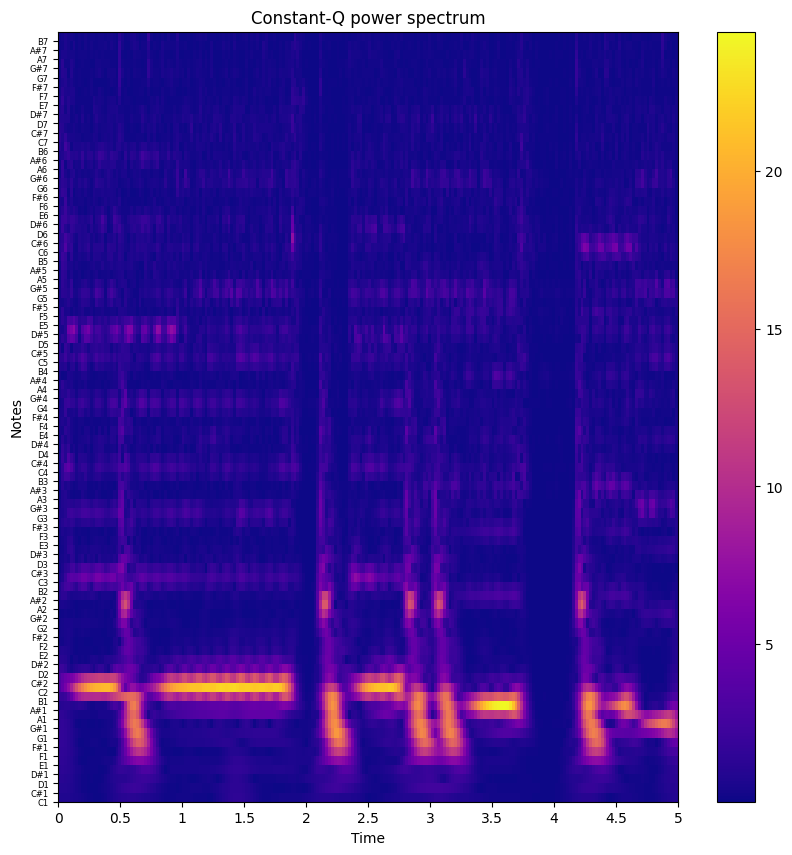

In [16]:
plot_cqt(y, y_cqt)

- The notes are nicely visible, with attack, duration, and decay.
- We can also see the spill-over into the adjacent bins.
- And the spill-over into the higher frequency octaves.

## CQT exploration chunk wise

In [17]:
def cqt_chunked_padded(cqt_obj, y, n_new: int = 1, n_carryover: int = 4, n_padding: int = 0, chunk_size_samples: int = 1024):
    n_new_samples = chunk_size_samples * n_new - 1
    n_carryover_samples = chunk_size_samples * n_carryover
    n_padding_samples = chunk_size_samples * n_padding

    n_new_frames = n_new_samples // slide_length
    n_carryover_frames = n_carryover_samples // slide_length
    n_padding_frames = n_padding_samples // slide_length
    
    y_cqt_chunked = []
    for i in range(n_carryover_samples, y.shape[-1] - n_new_samples, n_new_samples):  # NOTE: Running till end kills chroma computation
        chunk = y[i-n_carryover_samples:i+n_new_samples]
        if n_padding_samples > 0:
            chunk = np.pad(chunk, (0,n_padding_samples), mode="edge")
        chunk_cqt = cqt_obj.cqt(chunk)
        if n_padding_samples > 0:
            y_cqt_chunked.append(chunk_cqt[:,n_carryover_frames:-n_padding_frames])
        else:
            y_cqt_chunked.append(chunk_cqt[:,n_carryover_frames:])
    
    y_cqt_chunked = np.concat(y_cqt_chunked, axis=1)
    
    # pad end if required
    _pad_cqt = librosa.samples_to_frames(y.shape[-1], hop_length=hop_length) + 1 - y_cqt_chunked.shape[1]
    y_cqt_chunked = np.pad(y_cqt_chunked, ((0,0),(0,_pad_cqt)), mode="edge")

    return y_cqt_chunked

In [18]:
cqt_obj_test = af.CQT(
    num=n_octaves*n_notes_per_octave,
    samplate=sr,
    low_fre=low_freq,
    bin_per_octave=n_notes_per_octave,
    slide_length=slide_length,
    normal_type=SpectralFilterBankNormalType.AREA,  # SpectralFilterBankNormalType.NONE | AREA | BAND_WIDTH,
    is_scale=True,
    factor=2.,
    beta=0,
    window_type=af.type.WindowType.HANN,
)

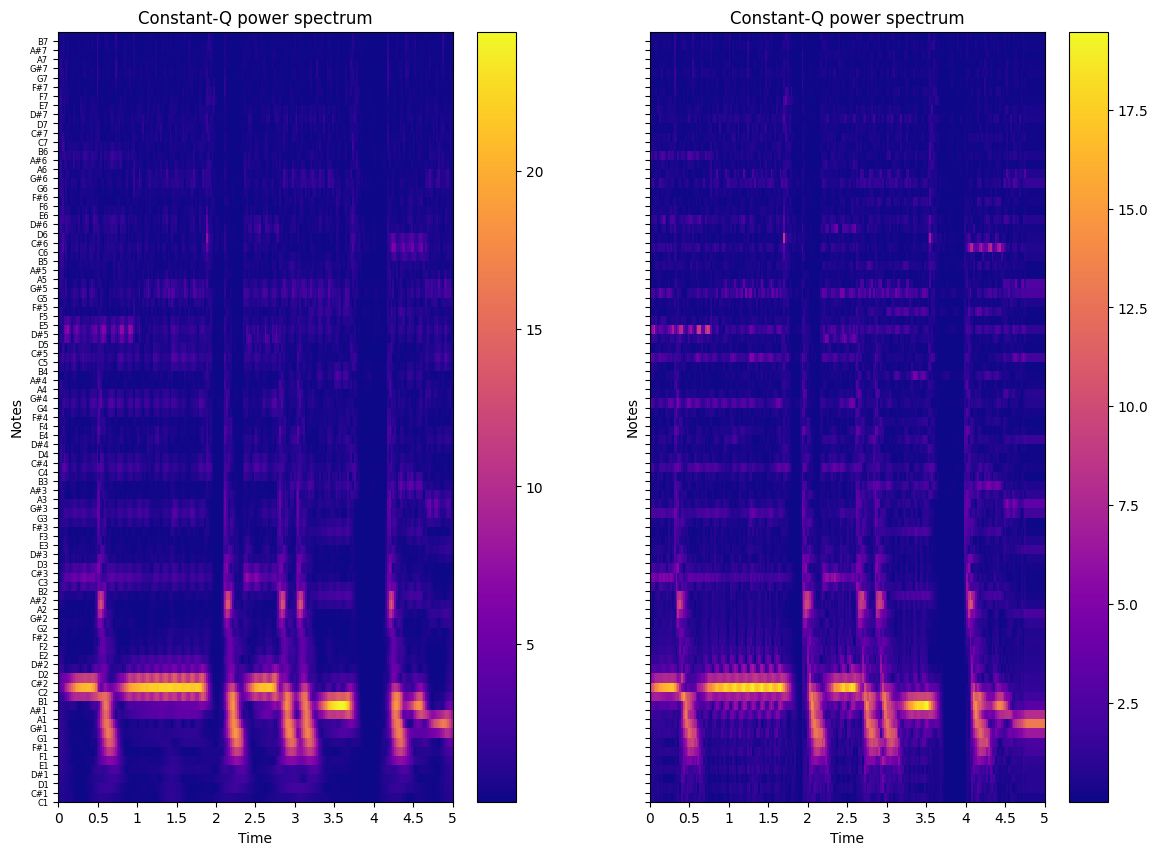

In [19]:
plot_cqts(
    y,
    y_cqt,
    #cqt_chunked_padded(cqt_obj, y, n_new=4, n_carryover=8),
    #cqt_chunked_padded(cqt_obj, y, n_new=1, n_carryover=8, n_padding=1),
    #cqt_chunked_padded(cqt_obj_test, y, n_new=1, n_carryover=8, n_padding=1),
    cqt_chunked_padded(cqt_obj_test, y, n_new=1, n_carryover=8, n_padding=1)
)

- CQT transfrom seem to produce artifacts at the borders: When using >1 new samples, the result looks inconsistent/chunked
  - We can improve on this by padding the chunk by 1 to the right; leads to more smooth results
- CQT tansfrom on chunks produces more spill-over into the adjacent buckets
  - Maybe other normalization or such? Nope, AREA is best normal_type
  - Using factor > 1, e.g. 1.5 or 2 reduces spill-over and makes main note / pitch stronger
  - beta doesn't seem to have any influence
- n_carryover:
  - simple notes 4+
  - more complex 8+
  - more doesn't seem to hurt; time requirements are limit here
- good cqt threshold
  - normed=NONE|AREA doesn't seem to make a difference
  - values vary a lot depending on sound type, sound acticity, etc.
    - easily from 1.25 to 12.5
  - best approach: quartile, I guess
    - can be done of chunk? or recent max?

### Normalizing the CQT

The value range is all over the place. To sensibly interprete it (or threshold it), it needs to be normalized.

- full audio CQT: use percentile near max (e.g. 0.995)
- chunked CQT: use max(sliding max (based on e.g. percentile 0.995), min_energy)

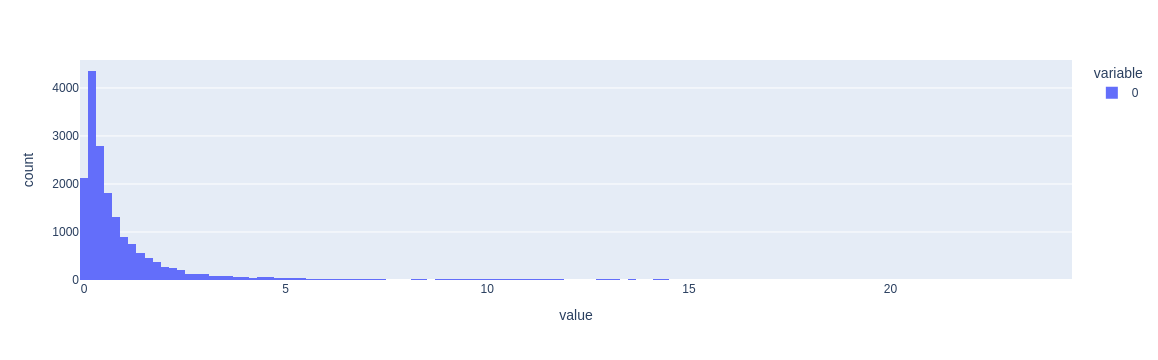

In [20]:
px.histogram(np.abs(y_cqt).flatten())

Very long right-sided tail.

In [21]:
q_thr = 0.995

In [22]:
# full audio version
#y_cqt_clipped = (np.abs(y_cqt) / np.quantile(np.abs(y_cqt), q_thr)).clip(0, 1)

# chunked version
y_cqt_chunked = cqt_chunked_padded(cqt_obj_test, y)
y_cqt_chunked_clipped = (np.abs(y_cqt_chunked) / np.quantile(np.abs(y_cqt_chunked), q_thr)).clip(0, 1)

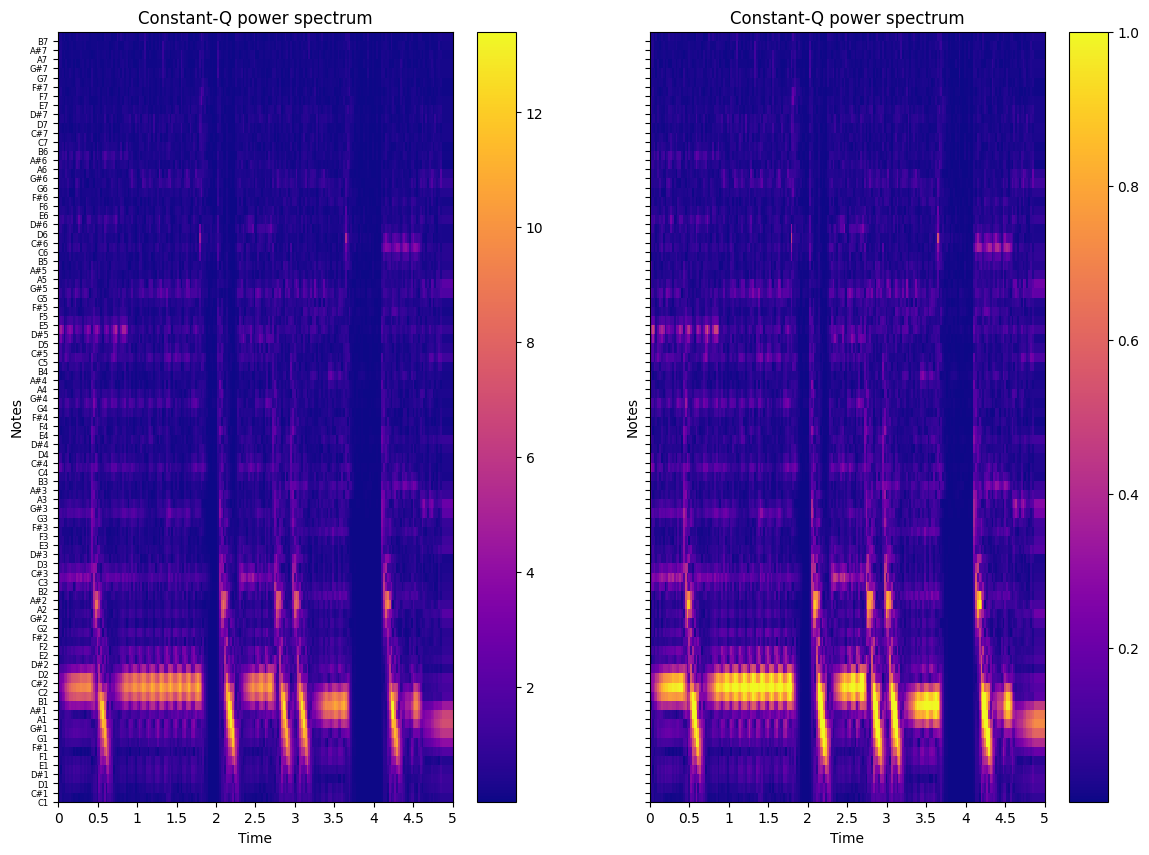

In [23]:
plot_cqts(
    y,
    #y_cqt,
    #y_cqt_clipped,
    y_cqt_chunked,
    y_cqt_chunked_clipped,
)

- using `q_thr = 0.995` qauntile as maximum normalization values works quite well on whole audio
- also seems to work on chunked version
- simply max normalizing might also work

### Thresholding the CQT

For some visualization, thresholding might be required. After normalization, we might be able to determine a single threshold to use globally.

Other visualizations should be able to deal with the CQT energy directly (e.g. through transparancy).

In [24]:
thr = 0.5

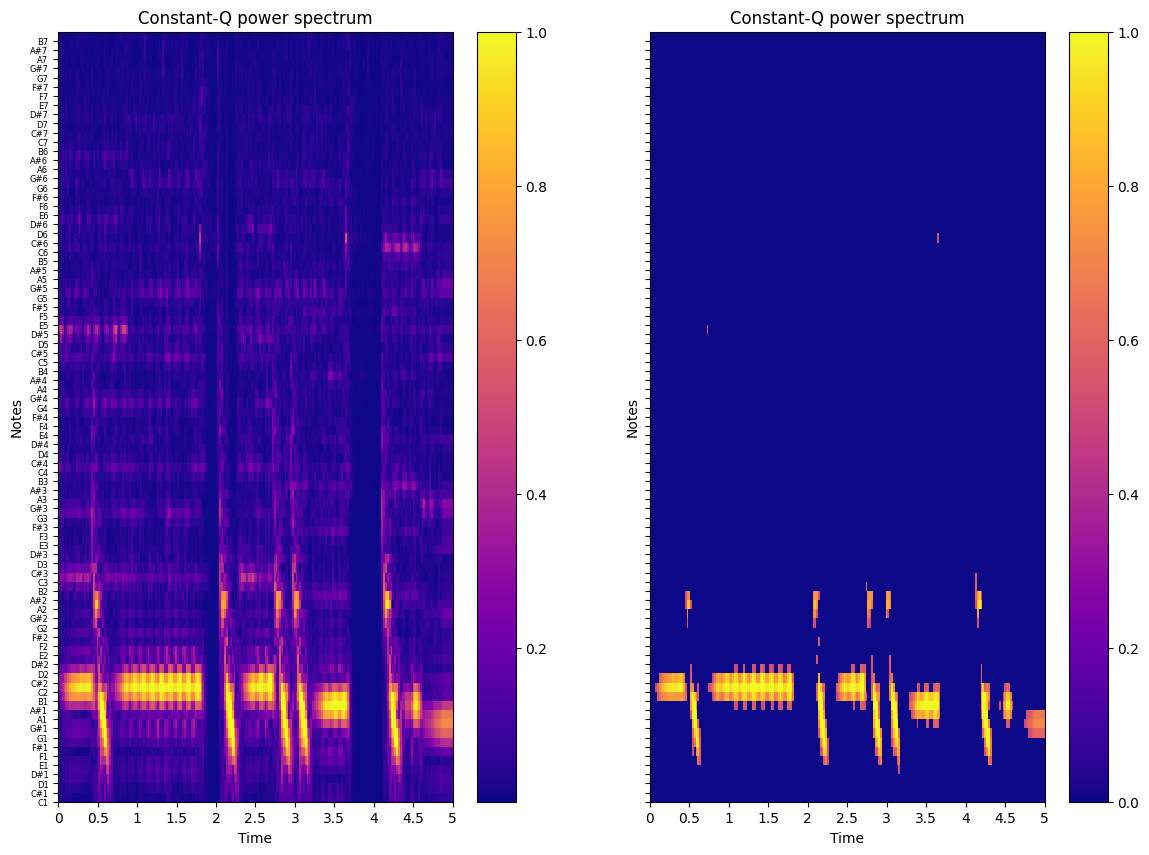

In [25]:
plot_cqts(
    y,
    #y_cqt_clipped,
    #np.where(y_cqt_clipped < thr, 0, y_cqt_clipped)
    y_cqt_chunked_clipped,
    np.where(y_cqt_chunked_clipped < thr, 0, y_cqt_chunked_clipped)
)

- thresholds: 0.6-0.8; 0.5-0.7; 0.65-0.85
- similar on chunked and full audio version; if applied posterior

### Normalizing during chunk processing

We don't have the whole spectogram available during chunk processing. Hence we have to apply a normalization term to each chunk.

In [94]:
def cqt_chunked_padded_normed(cqt_obj, y, n_new: int = 1, n_carryover: int = 4, n_padding: int = 0, q_thr: float=0.9999, chunk_size_samples: int = 1024):
    n_new_samples = chunk_size_samples * n_new - 1
    n_carryover_samples = chunk_size_samples * n_carryover
    n_padding_samples = chunk_size_samples * n_padding

    n_new_frames = n_new_samples // slide_length
    n_carryover_frames = n_carryover_samples // slide_length
    n_padding_frames = n_padding_samples // slide_length
    
    y_cqt_chunked = []
    running_max_value = 5  # the higer, the safer, but the slower the start; init value
    for i in range(n_carryover_samples, y.shape[-1] - n_new_samples, n_new_samples):  # NOTE: Running till end kills chroma computation
        chunk = y[i-n_carryover_samples:i+n_new_samples]
        if n_padding_samples > 0:
            chunk = np.pad(chunk, (0,n_padding_samples), mode="edge")
        chunk_cqt = cqt_obj.cqt(chunk)
        
        max_norm = np.abs(chunk_cqt).max()
        #max_norm = 0.9 * max_norm + 0.1 * np.quantile(np.abs(chunk_cqt), q_thr)
        #max_norm = max(max_norm, 5.0)
        n = 50
        running_max_value = (n-1)/n * running_max_value + 1/n * max_norm
        max_norm_limited = max(running_max_value, max_norm)
        #print(max_norm, running_max_value, max_norm_limited)
        
        chunk_cqt_normed = (np.abs(chunk_cqt) / max_norm_limited).clip(0, 1)
        
        if n_padding_samples > 0:
            y_cqt_chunked.append(chunk_cqt_normed[:,n_carryover_frames:-n_padding_frames])
        else:
            y_cqt_chunked.append(chunk_cqt_normed[:,n_carryover_frames:])
    
    y_cqt_chunked = np.concat(y_cqt_chunked, axis=1)
    
    # pad end if required
    _pad_cqt = librosa.samples_to_frames(y.shape[-1], hop_length=hop_length) + 1 - y_cqt_chunked.shape[1]
    y_cqt_chunked = np.pad(y_cqt_chunked, ((0,0),(0,_pad_cqt)), mode="edge")

    return y_cqt_chunked

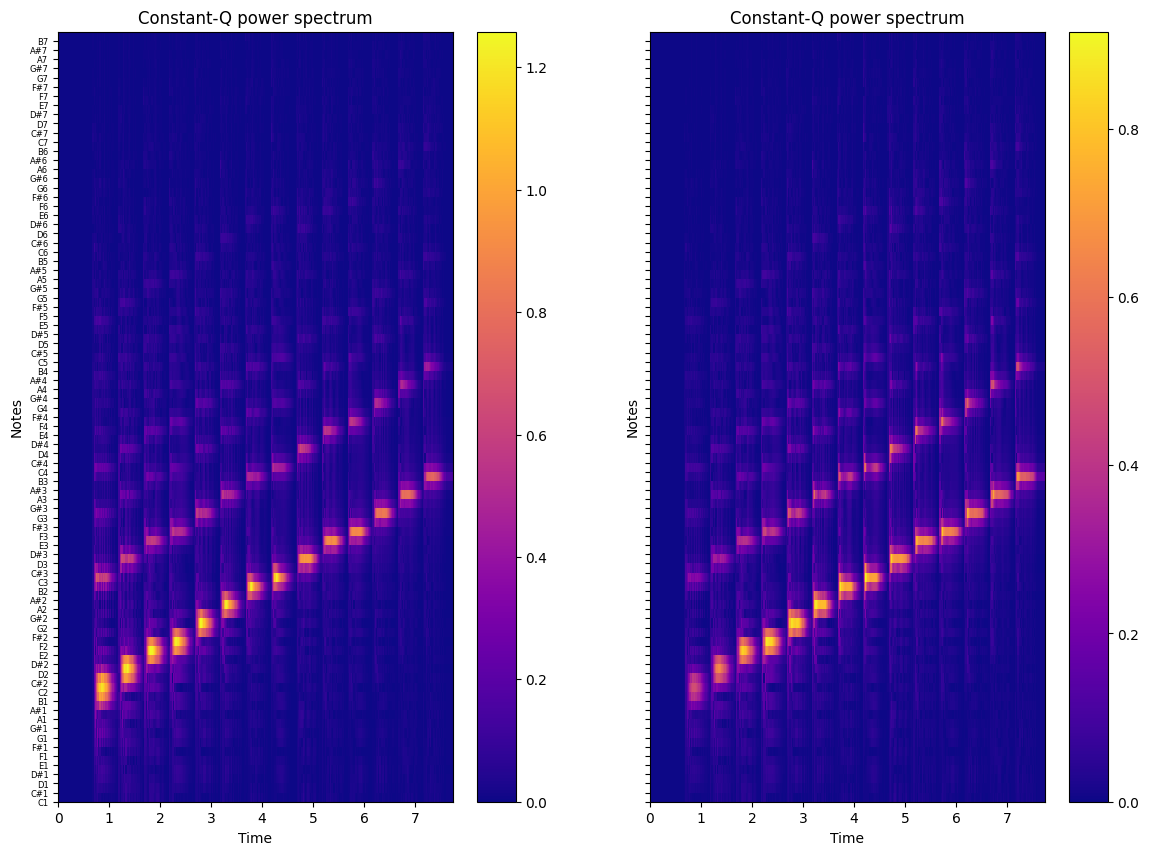

In [99]:
plot_cqts(
    y,
    cqt_chunked_padded(cqt_obj_test, y),
    cqt_chunked_padded_normed(cqt_obj_test, y)
)

Idea 1: Apply the same quantile threshold just on each chunk separately.
- First impression: less intense, aka would require lower threshold later, but quite ok. But does increase values in silent parts too much.

Idea 2: Running min max_norm value. Last `n=50` chunks are roughly considered.
- Works fine if parameters set nicely.
- Start with `running_max_value = 5`
- Each chunk, get chunk's max `max_norm = np.abs(chunk_cqt).max()`
- Update `running_max_value = (n-1)/n * running_max_value + 1/n * max_norm`
- Set max norm limit: `max_norm_limited = max(running_max_value, max_norm)`
- Normalize chunk accordingly: `(chunk / max_norm_limited).clip(0, 1)`

## Appendix

### Runtime total chunk processing
Should contain most of the necessary steps.

In [ ]:
def _process_chunk(running_max_value):
    chunk = y[:1024*9]
    chunk = np.pad(chunk, (0, 1), mode="edge")
    chunk_cqt = np.abs(cqt_obj.cqt(chunk))
    
    max_norm = chunk_cqt.max()
    running_max_value = 0.98 * running_max_value + 0.02 * max_norm
    max_norm_limited = max(running_max_value, max_norm)
    chunk_cqt_normed = (chunk_cqt / max_norm_limited).clip(0, 1)

In [107]:
%timeit _process_chunk(5)

985 μs ± 4.35 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


Could work. Should be able to process multiple audiostreams given that total processing time requirement most liekly < 20ms.

### Librosa based CQTs

In [52]:
y_cqt_lr = librosa.cqt(
    y,
    sr=sr,
    hop_length=hop_length,
    fmin=low_freq,
    n_bins=n_octaves*n_notes_per_octave,
    bins_per_octave=n_notes_per_octave,
    tuning=0.0,
    filter_scale=1,
    norm=1,
    sparsity=0.01,
    window="hann",
    scale=True,
    pad_mode="constant"
)

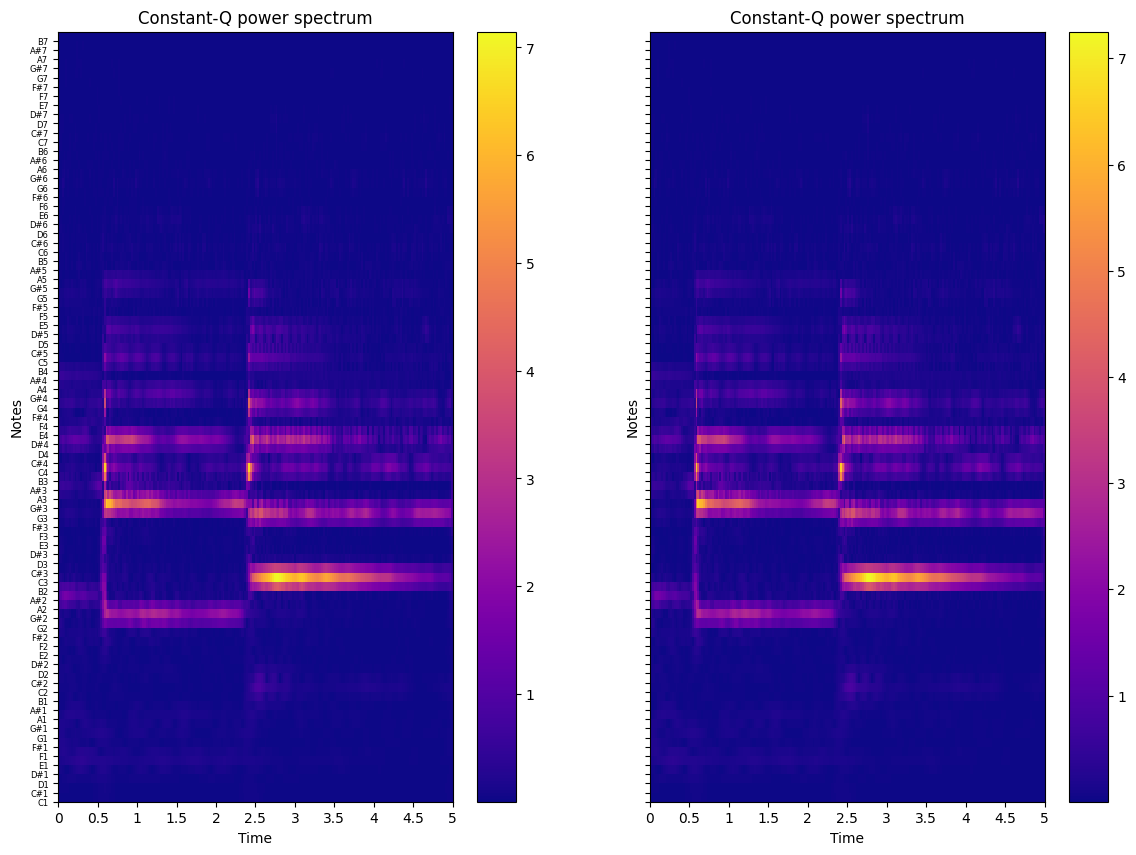

In [53]:
plot_cqts(
    y,
    y_cqt,
    y_cqt_lr,
)

With same settings, produces the same results as ausioflux's CQT.

In [54]:
y_cqt_lr_pseudo = librosa.pseudo_cqt(
    y,
    sr=sr,
    hop_length=hop_length,
    fmin=low_freq,
    n_bins=n_octaves*n_notes_per_octave,
    bins_per_octave=n_notes_per_octave,
    tuning=0.0,
    filter_scale=1,
    norm=1,
    sparsity=0.01,
    window="hann",
    scale=True,
    pad_mode="constant"
)

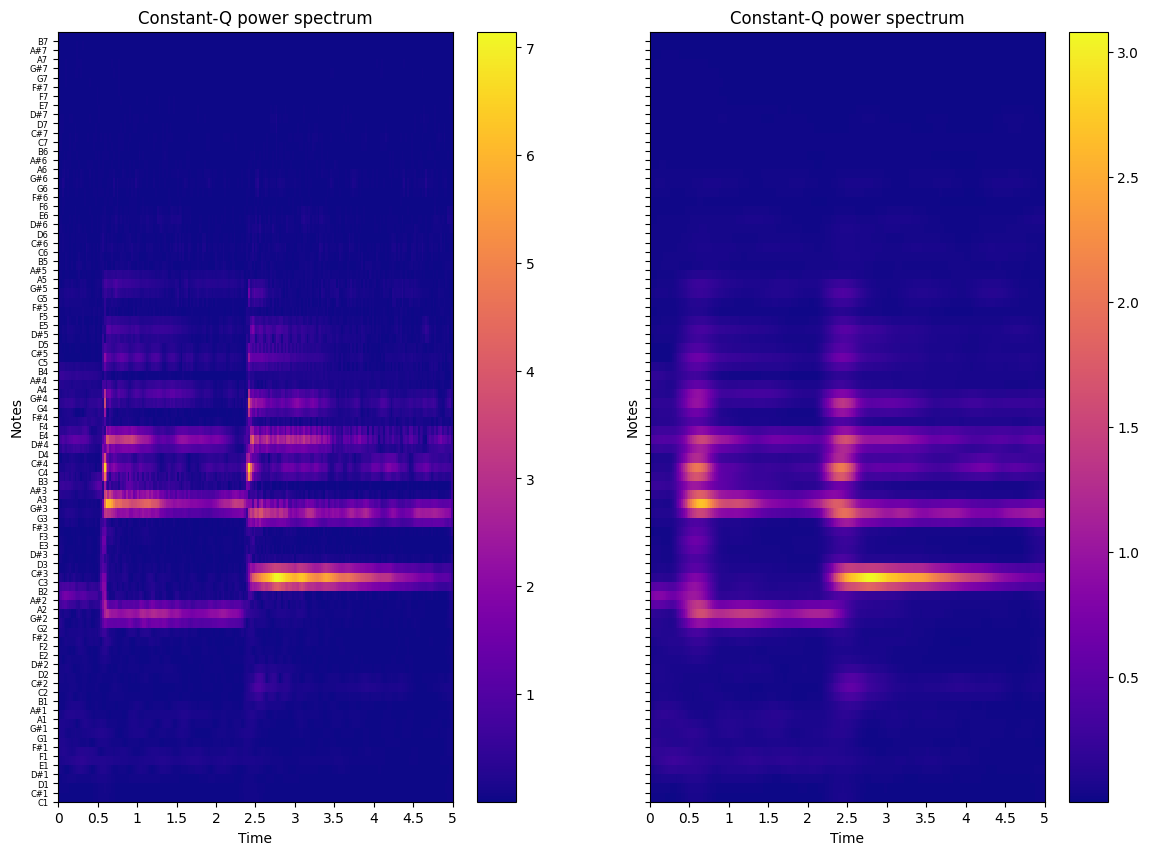

In [55]:
plot_cqts(
    y,
    y_cqt,
    y_cqt_lr_pseudo,
)

Pseudo-CQT is way less crisp, but might have it's uses.

In [154]:
y_cqt_lr_hybrid = librosa.hybrid_cqt(
    y,
    sr=sr,
    hop_length=hop_length,
    fmin=low_freq,
    n_bins=n_octaves*n_notes_per_octave,
    bins_per_octave=n_notes_per_octave,
    tuning=0.0,
    filter_scale=1,
    norm=1,
    sparsity=0.01,
    window="hann",
    scale=True,
    pad_mode="constant"
)

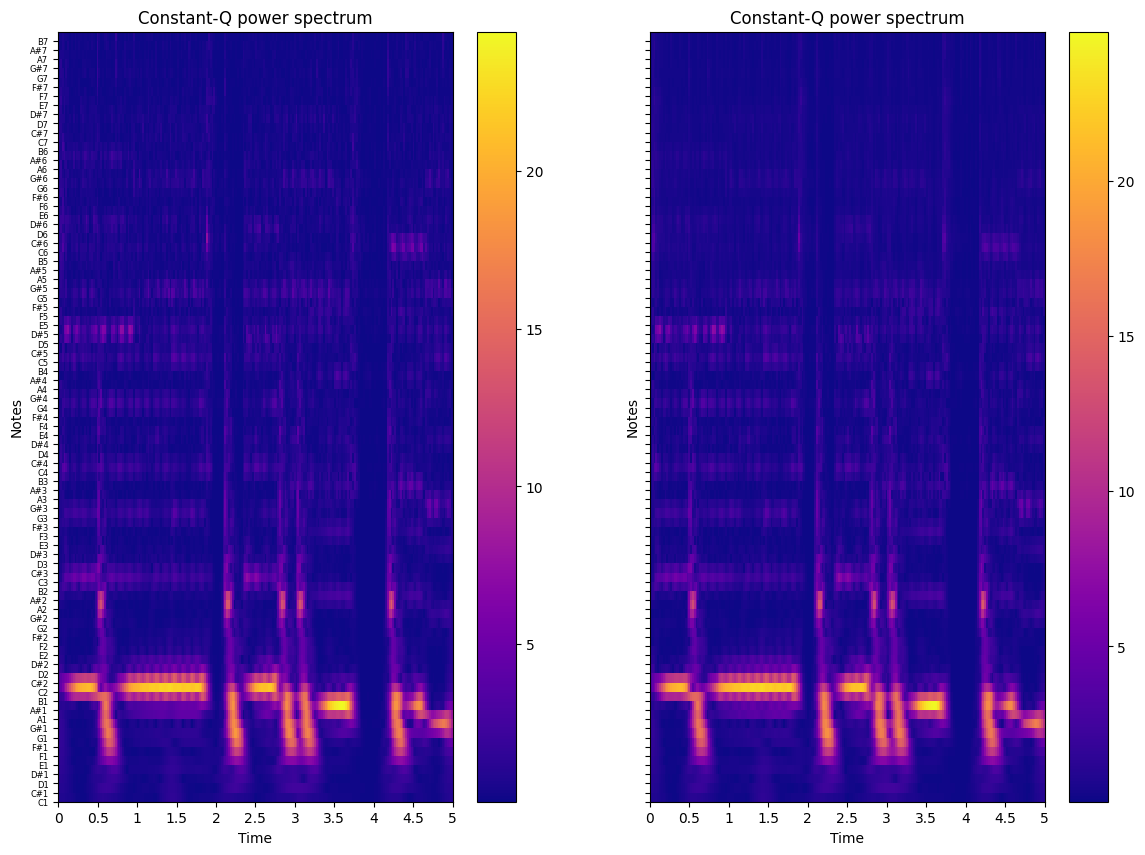

In [155]:
plot_cqts(
    y,
    y_cqt,
    y_cqt_lr_hybrid,
)hybrid_cqt

As advertised, more smoothed out in the higher frequencies - not sure if we care about those.

### Runtime comparison

In [158]:
%timeit cqt_obj.cqt(y)

21.3 ms ± 507 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [160]:
%timeit librosa.cqt(y, sr=sr, hop_length=hop_length, fmin=low_freq, n_bins=n_octaves*n_notes_per_octave, bins_per_octave=n_notes_per_octave, tuning=0.0, filter_scale=1, norm=1, sparsity=0.01, window="hann", scale=True, pad_mode="constant")

16.8 ms ± 413 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [161]:
%timeit librosa.pseudo_cqt(y, sr=sr, hop_length=hop_length, fmin=low_freq, n_bins=n_octaves*n_notes_per_octave, bins_per_octave=n_notes_per_octave, tuning=0.0, filter_scale=1, norm=1, sparsity=0.01, window="hann", scale=True, pad_mode="constant")

143 ms ± 3.94 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [162]:
%timeit librosa.hybrid_cqt(y, sr=sr, hop_length=hop_length, fmin=low_freq, n_bins=n_octaves*n_notes_per_octave, bins_per_octave=n_notes_per_octave, tuning=0.0, filter_scale=1, norm=1, sparsity=0.01, window="hann", scale=True, pad_mode="constant")

18.4 ms ± 277 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


The librosa CQT is actually faster on the whole audio segment (tested on 5s).

In [176]:
chunk = y[:1024*32]

In [178]:
%timeit cqt_obj.cqt(chunk)

3.5 ms ± 388 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [177]:
%timeit librosa.cqt(chunk, sr=sr, hop_length=hop_length, fmin=low_freq, n_bins=n_octaves*n_notes_per_octave, bins_per_octave=n_notes_per_octave, tuning=0.0, filter_scale=1, norm=1, sparsity=0.01, window="hann", scale=True, pad_mode="constant")

13.7 ms ± 29.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


But a good deal slower on small chunks of audio.